# MARL-mixed — multi-agent learning dynamics

This notebook summarizes the experiments added to **MARL-mixed**:

1. **JaxMARL sweep** — IPPO trained on *every registered JaxMARL environment*
   (one SLURM array task per game, GPU each), logging the learning dynamics.
2. **CRLD observability study** — the 2-agent / N-agent Iterated Prisoner's
   Dilemma with heterogeneous observability (deterministic learning dynamics).

Everything below is generated from saved artifacts in `results/` — no training
or GPU needed to re-run the notebook.

In [1]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
RESULTS = os.path.join(HERE, "results")
REPO = os.path.dirname(HERE)
pd.set_option("display.max_rows", 100)
print("results dir:", RESULTS)

results dir: /nas/ucb/marimeireles/MARL-mixed/jaxmarl_env/results


## 1. Coverage across all JaxMARL environments

Each environment produced a `.status` file (`ok` / `skipped:<reason>` /
`failed:<reason>`). A single feed-forward, **discrete-action** IPPO trains the
discrete games directly; continuous-action games need a Gaussian policy head
(added separately) and a few image/dict-observation games need a CNN encoder.

In [2]:
rows = []
for s in sorted(glob.glob(os.path.join(RESULTS, "*.status"))):
    env = os.path.basename(s)[:-7]
    st = open(s).read().strip()
    kind = st.split(":", 1)[0]
    reason = st.split(":", 1)[1] if ":" in st else ""
    rows.append(dict(environment=env, status=kind, reason=reason))
cov = pd.DataFrame(rows)
summary = cov["status"].value_counts().rename("count").to_frame()
print(summary)
cov

        count
status       
ok         25
failed      5


,environment,status,reason
0,HeuristicEnemySMAX,ok,
1,LearnedPolicyEnemySMAX,failed,"TypeError(""LearnedPolicyEnemySMAX.__init__() m..."
2,MPE_simple_adversary_v3,ok,
3,MPE_simple_crypto_v3,ok,
4,MPE_simple_facmac_3a_v1,ok,
5,MPE_simple_facmac_6a_v1,ok,
6,MPE_simple_facmac_9a_v1,ok,
7,MPE_simple_facmac_v1,ok,
8,MPE_simple_push_v3,ok,
9,MPE_simple_reference_v3,ok,


## 2. Learning dynamics of the trained games

Reward per step vs. environment steps. Most games show clear improvement; hard exploration games (SMAX) stay near flat at this budget.

In [3]:
trained = []
for f in sorted(glob.glob(os.path.join(RESULTS, "*.npz"))):
    d = np.load(f)
    env = os.path.basename(f)[:-4]
    y = d["dynamics"]
    trained.append(dict(environment=env,
                        n_agents=int(d["num_agents"]),
                        reward_start=round(float(y[0]), 3),
                        reward_end=round(float(y[-1]), 3),
                        delta=round(float(y[-1] - y[0]), 3),
                        updates=len(y)))
perf = pd.DataFrame(trained).sort_values("delta", ascending=False).reset_index(drop=True)
perf

,environment,n_agents,reward_start,reward_end,delta,updates
0,MPE_simple_v3,1,-1.561,-0.259,1.302,610
1,ant_4x2,4,-0.210,0.793,1.004,610
2,MPE_simple_speaker_listener_v4,2,-1.467,-0.592,0.875,610
3,overcooked,2,0.000,0.623,0.623,610
4,MPE_simple_facmac_9a_v1,12,1.035,1.566,0.531,610
5,MPE_simple_reference_v3,2,-1.109,-0.685,0.424,610
6,MPE_simple_facmac_v1,4,0.027,0.371,0.343,610
7,MPE_simple_facmac_3a_v1,4,0.032,0.370,0.338,610
8,MPE_simple_push_v3,2,-0.576,-0.289,0.288,610
9,MPE_simple_spread_v3,3,-1.071,-0.786,0.285,610


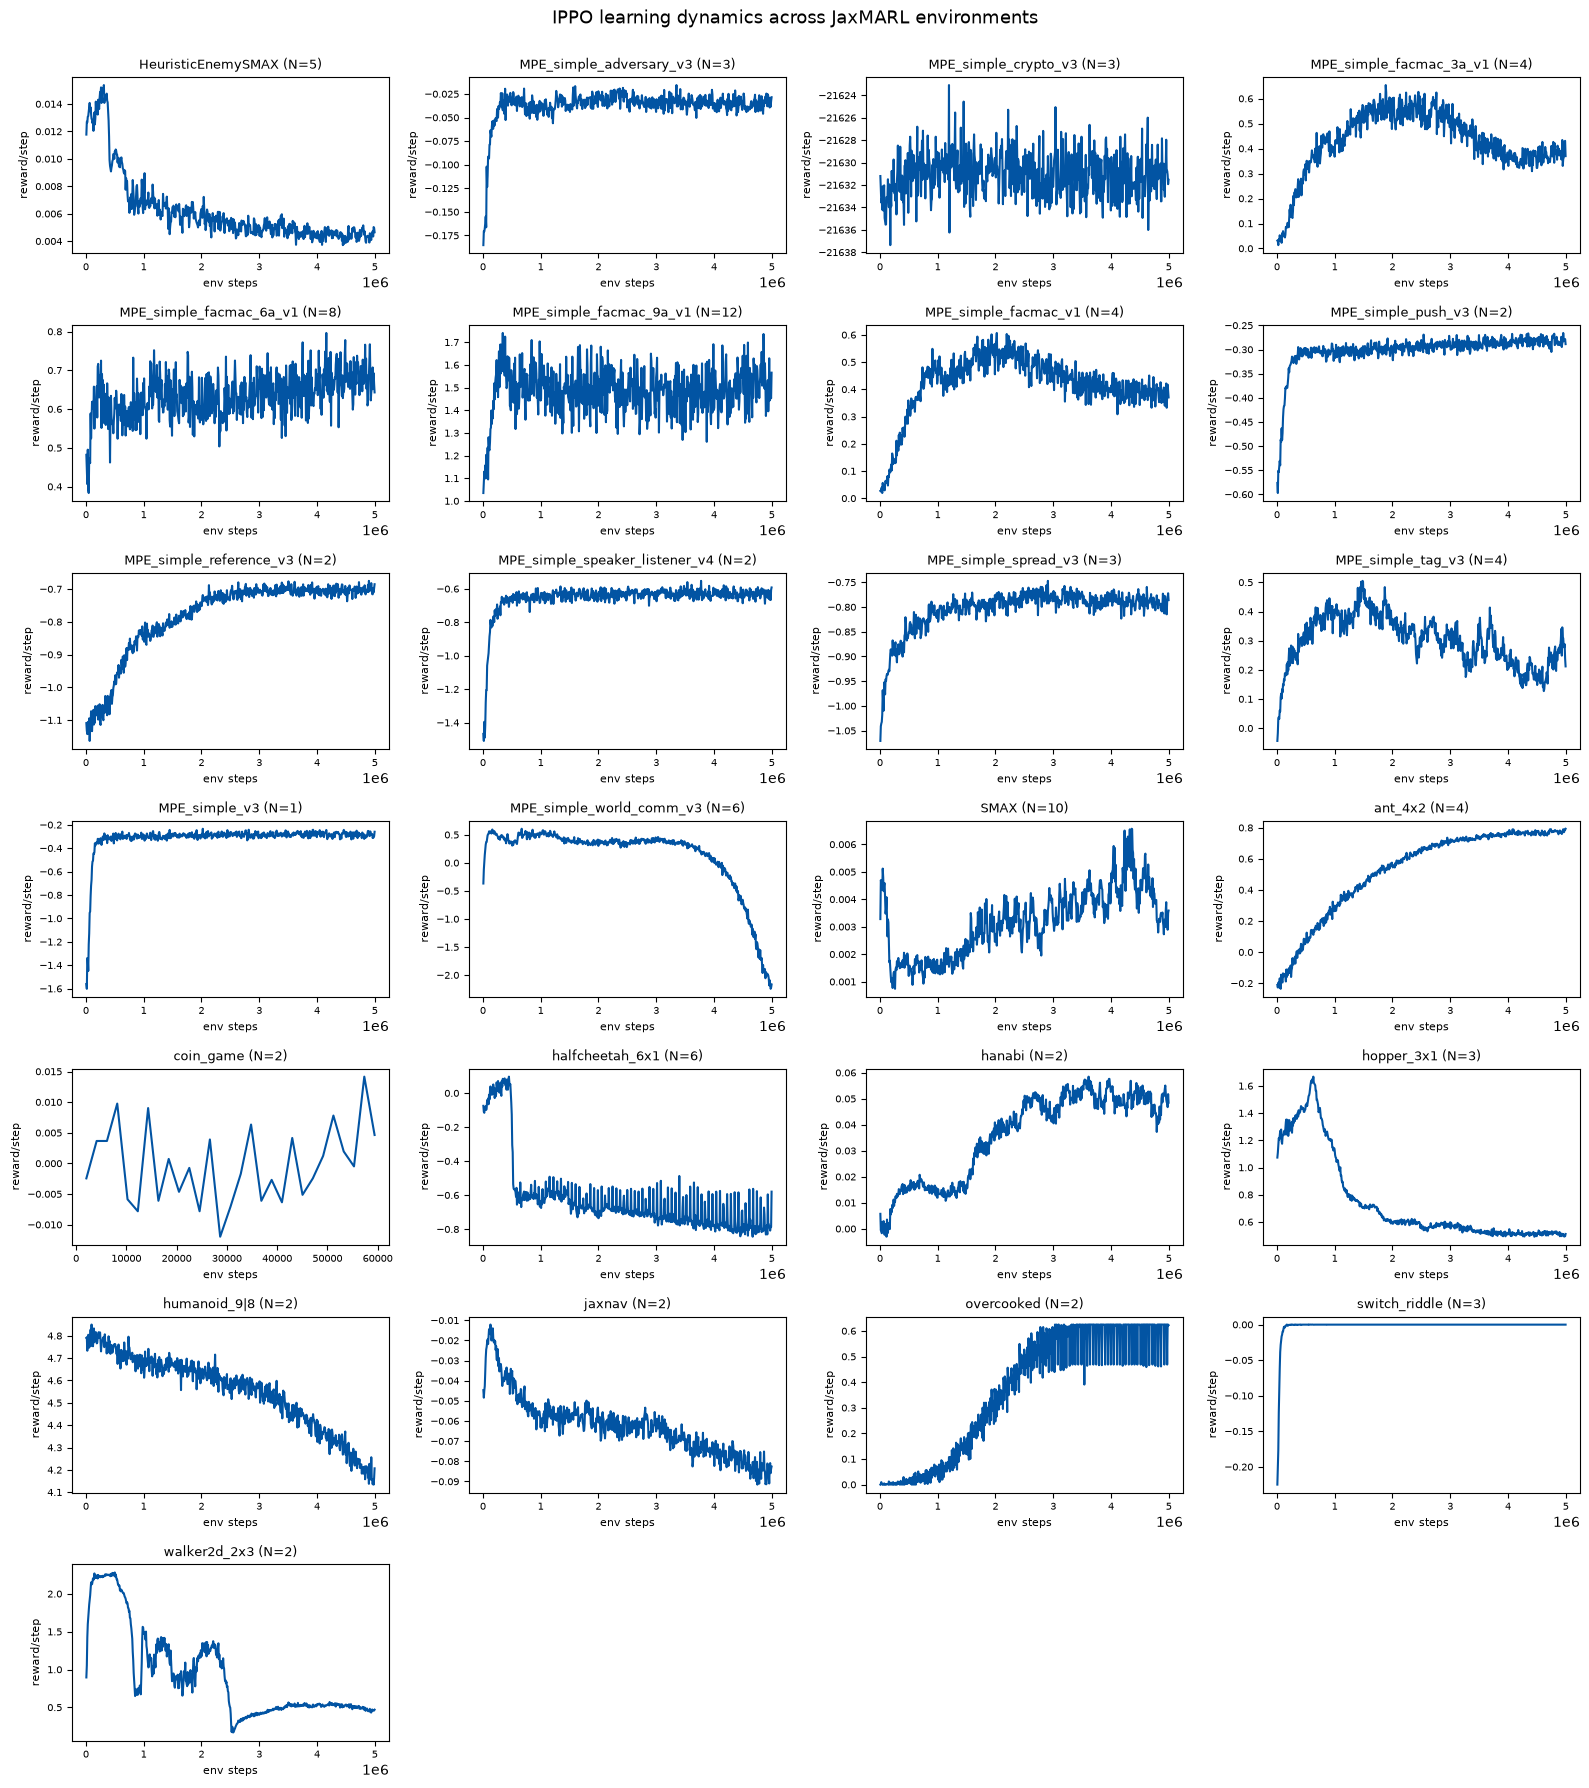

In [4]:
files = sorted(glob.glob(os.path.join(RESULTS, "*.npz")))
ncol = 4; nrow = (len(files) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol, 2.6*nrow), squeeze=False)
for ax in axes.flat: ax.axis("off")
for k, f in enumerate(files):
    d = np.load(f); ax = axes[k//ncol][k%ncol]; ax.axis("on")
    ax.plot(d["timesteps"], d["dynamics"], color="#0254a3")
    ax.set_title(f"{os.path.basename(f)[:-4]} (N={int(d['num_agents'])})", fontsize=9)
    ax.set_xlabel("env steps", fontsize=8); ax.set_ylabel("reward/step", fontsize=8)
    ax.tick_params(labelsize=7)
fig.suptitle("IPPO learning dynamics across JaxMARL environments", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()

### Skipped & failed — and why

- **skipped: continuous action space** — MaBrax robotic-control envs and the
  FACMAC MPE variants use `Box` actions; handled by the Gaussian-policy run
  (Section 4).
- **failed** — environment-specific API quirks (dict/image observations, a
  `make()` that needs extra args). Each is a localized follow-up.

In [5]:
notok = cov[cov.status != "ok"][["environment", "status", "reason"]]
notok.reset_index(drop=True)

,environment,status,reason
0,LearnedPolicyEnemySMAX,failed,"TypeError(""LearnedPolicyEnemySMAX.__init__() m..."
1,overcooked_v2,failed,TypeError('OvercookedV2.observation_space() ta...
2,storm,failed,"AttributeError(""'dict' object has no attribute..."
3,storm_2p,failed,"AttributeError(""'dict' object has no attribute..."
4,storm_np,failed,ValueError('Incompatible shapes for broadcasti...


## 3. Continuous control (MaBrax) — Gaussian policy

The discrete sweep above skips `Box`-action games. A Gaussian policy head lets
IPPO train the MaBrax robotic-control suite (`ant_4x2`, `halfcheetah_6x1`,
`hopper_3x1`, `humanoid_9|8`, `walker2d_2x3`). Their curves are loaded below once
that run has completed (look for `*_mabrax` / continuous entries in the table
above).

*This section auto-populates from the same `results/` directory, so re-running
the notebook after the MaBrax sweep finishes will show the new curves with no
code changes.*

In [6]:
mabrax = [r for r in trained if r["environment"] in
          {"ant_4x2","halfcheetah_6x1","hopper_3x1","humanoid_9|8","walker2d_2x3"}]
if mabrax:
    display(pd.DataFrame(mabrax))
else:
    print("MaBrax continuous results not present yet — run the Gaussian sweep, "
          "then re-execute this notebook.")

,environment,n_agents,reward_start,reward_end,delta,updates
0,ant_4x2,4,-0.210,0.793,1.004,610
1,halfcheetah_6x1,6,-0.075,-0.579,-0.504,610
2,hopper_3x1,3,1.073,0.511,-0.562,610
3,humanoid_9|8,2,4.791,4.207,-0.584,610
4,walker2d_2x3,2,0.895,0.470,-0.426,610


## 4. CRLD observability study (the original research question)

Before the deep-RL sweep, the core study uses **collective reinforcement
learning dynamics** (CRLD, the deterministic learning-dynamics limit) on the
Iterated Prisoner's Dilemma with *heterogeneous observability*: one agent sees
the full interaction, the other is selectively blind.

Key reproduced finding: **cooperation is fragile** — defection is the modal
attractor, and impairing observability suppresses cooperation monotonically;
losing the ability to observe one's *own* last action is uniquely catastrophic.

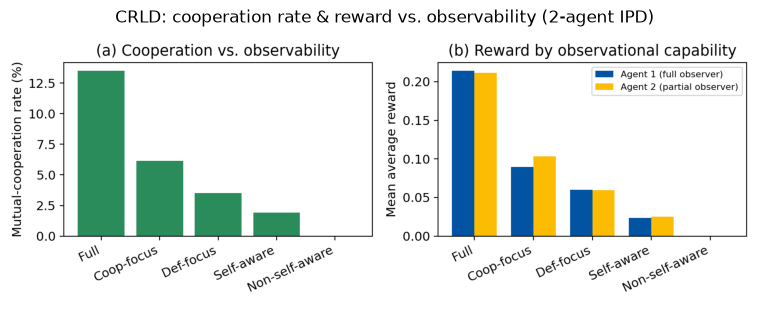

In [7]:
summ = os.path.join(REPO, "paper", "figures", "summary.png")
if os.path.exists(summ):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(11, 3.6)); ax.imshow(mpimg.imread(summ)); ax.axis("off")
    ax.set_title("CRLD: cooperation rate & reward vs. observability (2-agent IPD)")
    plt.show()
else:
    print("summary figure not found:", summ)

In [8]:
# N-agent extension: cooperation rate as a function of #agents x regime
csv = os.path.join(HERE, "coop_table.csv")
if os.path.exists(csv):
    display(pd.read_csv(csv))
else:
    print("coop_table.csv not found")

,regime,N=2,N=3,N=4
0,full,0.0,0.0,0.0
1,blind,0.0,0.0,0.0
2,self,0.0,0.0,0.0
3,others,0.0,0.0,0.0


## 5. CRLD flow plots — the dynamics of cooperation, done properly

The trajectory-only portraits above show *a* path, but not the **flow** that
produced it. In the CRLD (deterministic learning-dynamics) framework we can draw
the actual **vector field** of the learning update in strategy space — this is
`pyCRLD`'s `fp.plot_strategy_flow` — with trajectories overlaid. The flow field
needs the analytic dynamics object (`mae`), so it is a CRLD construct: it exists
for the social-dilemma games, not for the sampled deep-RL runs.

The cell below runs the canonical example *live* (pyCRLD now runs in the same
Python 3.11 environment as JaxMARL — forced onto CPU for the small CRLD compute).

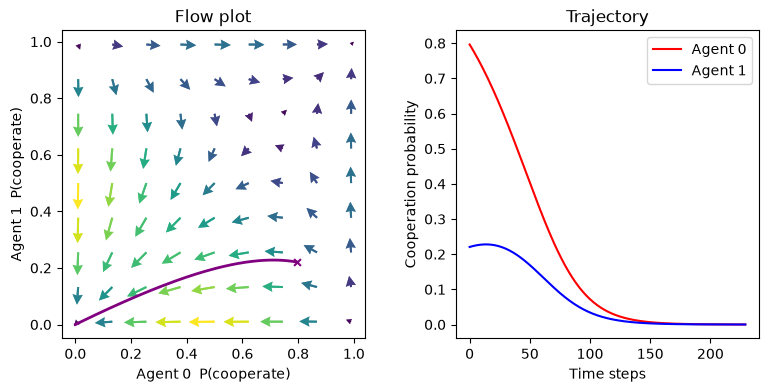

In [9]:
import os as _os
_os.environ.setdefault("JAX_PLATFORMS", "cpu")   # CRLD compute is tiny; CPU avoids GPU setup
import sys as _sys
_sys.path.insert(0, REPO)
import numpy as _np
from pyCRLD.Agents.StrategyActorCritic import stratAC
from pyCRLD.Environments.SocialDilemma import SocialDilemma
from pyCRLD.Utils import FlowPlot as fp

env = SocialDilemma(R=1.0, T=0.8, S=-0.5, P=0.0)
mae = stratAC(env=env, learning_rates=0.1, discount_factors=0.9)
_np.random.seed(0)
xtraj, reached = mae.trajectory(mae.random_softmax_strategy(), Tmax=10000, tolerance=1e-5)

fig, axs = plt.subplots(1, 2, figsize=(9, 4)); plt.subplots_adjust(wspace=0.3)
xs = ([0], [0], [0]); ys = ([1], [0], [0])
ax = fp.plot_strategy_flow(mae, xs, ys, use_RPEarrows=False,
                           flowarrow_points=_np.linspace(0.01, 0.99, 9), axes=[axs[0]])
fp.plot_trajectories([xtraj], xs, ys, cols=["purple"], axes=ax)
axs[0].set_xlabel("Agent 0  P(cooperate)"); axs[0].set_ylabel("Agent 1  P(cooperate)")
axs[0].set_title("Flow plot")
axs[1].plot(xtraj[:, 0, 0, 0], label="Agent 0", c="red")
axs[1].plot(xtraj[:, 1, 0, 0], label="Agent 1", c="blue")
axs[1].set_xlabel("Time steps"); axs[1].set_ylabel("Cooperation probability")
axs[1].legend(); axs[1].set_title("Trajectory")
plt.show()

Sweeping the temptation `T` moves the game along the dilemma axis — and the
flow reorganizes from cooperation-attracting (Harmony) to defection-attracting
(Prisoner's Dilemma). Purple lines are trajectories from several random starts.

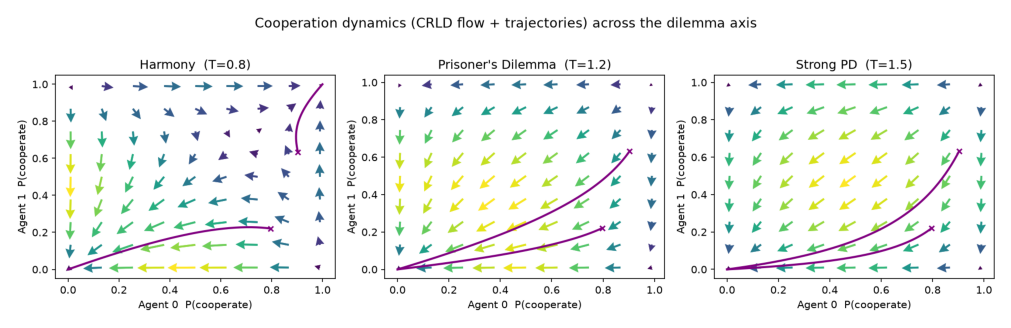

In [10]:
img = os.path.join(RESULTS, "payoff_sweep.png")
if os.path.exists(img):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(13, 4)); ax.imshow(mpimg.imread(img)); ax.axis("off")
    plt.show()
else:
    print("run scratch_repro/flowplots.py to generate payoff_sweep.png")

### Observation heterogeneity, with the flow field

Now the actual research question, *with arrows*: a **memory-1** IPD where Agent 1's
observability is degraded, shown in the state where both agents just cooperated
(where reciprocity lives). The colored arrows are the learning-dynamics flow; the
two purple lines are trajectories from random starts. Under **full** observability
the flow has structure that can sustain cooperation; as Agent 1 loses sight of its
own action (**self-aware**), the other's action (**non-self-aware**), or everything
(**blind**), the flow reorganizes toward mutual defection — the blind field points
almost uniformly to (0, 0).

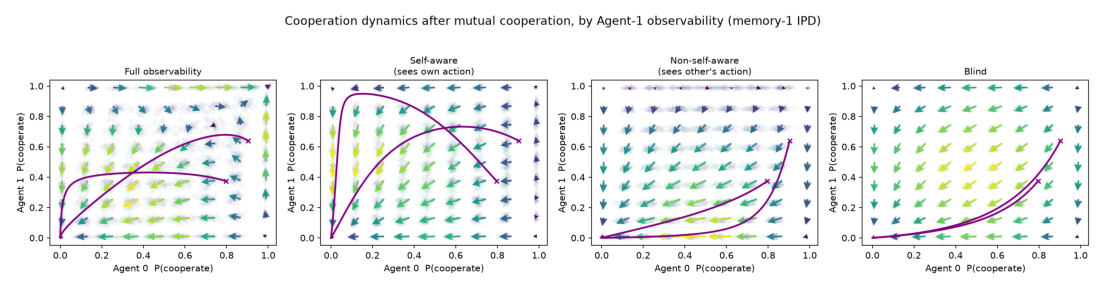

In [11]:
img = os.path.join(RESULTS, "memory_observability.png")
if os.path.exists(img):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(14, 4)); ax.imshow(mpimg.imread(img)); ax.axis("off")
    plt.show()
else:
    print("run scratch_repro/flowplots.py to generate memory_observability.png")

## 6. Cooperation phase portraits in deep RL — *why these have no arrows*

The plots below are the **sampled deep-RL** analogue: P(cooperate) trajectories
from IPPO on the same observability regimes. They have **no flow-field arrows on
purpose** — a flow field is the *analytic* learning-dynamics vector field, which
only exists for the CRLD model (Section 5). Neural-network policies trained by
sampling give you the realized *path*, but not a closed-form update direction at
every point in strategy space, so there is nothing to draw arrows from. (This is
the same reason the broader JaxMARL games in Section 2 get reward curves, not flow
plots.) Here every regime collapses to mutual defection — the deep-RL echo of the
CRLD result.

For the games where **cooperation** is genuinely defined (the mixed-motive
social dilemma), we can draw the *dynamics of cooperation* directly, in the
style of pyCRLD's `fp.plot_trajectories`: train IPPO while logging each agent's
cooperation frequency P(play C) per update, then trace the joint policy's path
through the **(agent-1 cooperation, agent-2 cooperation)** plane.

Below: the heterogeneous-observation memory-1 IPD (N=2) under each observability
regime. `x` marks the (random) start, `o` the converged policy. Under every
regime the trajectory collapses toward mutual defection (0, 0) — the deep-RL
echo of the CRLD result that defection is the dominant attractor; the regimes
differ in *how* they get there and how much residual cooperation survives.

*(Most JaxMARL games are forced-cooperative or non-dilemma, so a C/D cooperation
axis is not defined for them — for those, the reward curves in Section 2 are the
learning dynamics.)*

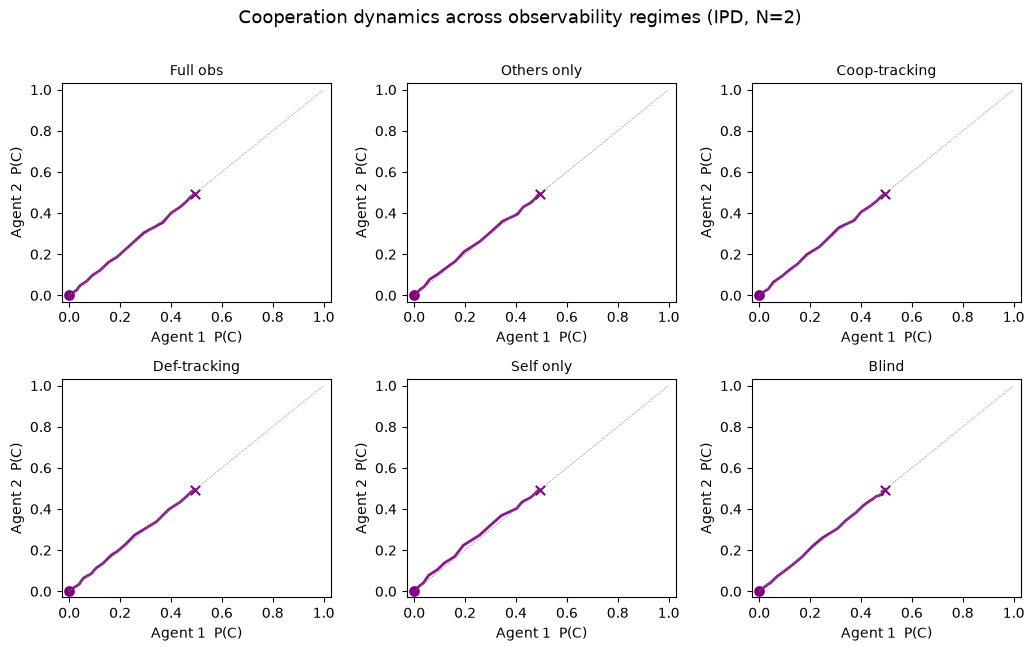

In [12]:
coop = sorted(f for f in glob.glob(os.path.join(RESULTS, "coop_*.npy"))
              if "vs_n" not in f)   # regime trajectories only
if coop:
    names = {"full":"Full obs","blind":"Blind","self":"Self only","others":"Others only",
             "coop":"Coop-tracking","def":"Def-tracking"}
    order = ["full","others","coop","def","self","blind"]
    have = {os.path.basename(f)[5:-4]: np.load(f) for f in coop}
    regs = [r for r in order if r in have] + [r for r in have if r not in order]
    ncol = 3; nrow = (len(regs)+ncol-1)//ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.5*ncol, 3.3*nrow), squeeze=False)
    for ax in axes.flat: ax.axis("off")
    for k, r in enumerate(regs):
        t = have[r]; ax = axes[k//ncol][k%ncol]; ax.axis("on")
        ax.plot(t[:,0], t[:,1], lw=2, color="purple", alpha=0.9)
        ax.scatter(t[0,0], t[0,1], color="purple", marker="x", s=45)
        ax.scatter(t[-1,0], t[-1,1], color="purple", marker="o", s=45)
        ax.plot([0,1],[0,1], ls=":", c="gray", lw=0.7)
        ax.set_xlim(-0.03,1.03); ax.set_ylim(-0.03,1.03)
        ax.set_title(names.get(r,r), fontsize=10)
        ax.set_xlabel("Agent 1  P(C)"); ax.set_ylabel("Agent 2  P(C)")
    fig.suptitle("Cooperation dynamics across observability regimes (IPD, N=2)", fontsize=13)
    fig.tight_layout(rect=[0,0,1,0.97]); plt.show()
    pd.DataFrame([{"regime":r,
                   "start": tuple(np.round(have[r][0],2)),
                   "end": tuple(np.round(have[r][-1],2))} for r in regs])
else:
    print("coop_*.npy not present yet — run coop_trajectories.py")

## 7. What was added to this repository

| path | what it is |
|---|---|
| `jaxmarl_env/heterogeneous_ipd.py` | N-player memory-1 IPD as a JaxMARL `MultiAgentEnv`, 6 observability regimes |
| `jaxmarl_env/train_ippo.py` | shared-policy feed-forward IPPO for the IPD (discrete) |
| `jaxmarl_env/run_all.py` | generic IPPO driver: trains one JaxMARL env, logs dynamics (discrete **and** Gaussian-continuous) |
| `jaxmarl_env/slurm_sweep.sh` | SLURM array job — one task per registered env |
| `jaxmarl_env/plot_all.py` | coverage report + combined dynamics grid |
| `jaxmarl_env/sweep_table.py` | regime x N cooperation table for the IPD |
| `jaxmarl_env/results/` | per-env `.npz` curves, `.png`, `.status` |
| `scratch_repro/` | CRLD reproduction scripts (deterministic IPD dynamics) |
| `paper/` | corrected write-up + regenerated figures |
| `.venv-jaxmarl/` | Python 3.11 env (uv) with JaxMARL + CUDA jax 0.4.38 (git-ignored) |

Two interpreters are used deliberately: the CRLD code runs on the repo's
Python 3.8 / jax 0.4.13; the JaxMARL code runs in `.venv-jaxmarl` (Python 3.11).